In [ ]:
import pandas as pd
import numpy as np

print("Loading dataset (this may take 30–60 seconds)...")
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading dataset (this may take 30–60 seconds)...
Loaded: 1,457,392 rows × 151 columns


In [ ]:
status_map = {
    "Fully Paid":                                           0,
    "Does not meet the credit policy. Status:Fully Paid":  0,
    "Charged Off":                                          1,
    "Default":                                              1,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

df["default"] = df["loan_status"].map(status_map)
before = len(df)
df = df.dropna(subset=["default"])
df["default"] = df["default"].astype(int)
after = len(df)

print(f"Dropped {before - after:,} rows with unresolved loan status")
print(f"Remaining: {after:,} rows")
print(f"Default rate: {df['default'].mean():.1%}")

Dropped 558,814 rows with unresolved loan status
Remaining: 898,578 rows
Default rate: 20.3%


In [ ]:
leakage_cols = [
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_fico_range_high", "last_fico_range_low", "last_credit_pull_d",
    "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",
    "deferral_term", "hardship_amount", "hardship_start_date", "hardship_end_date",
    "payment_plan_start_date", "hardship_length", "hardship_dpd",
    "hardship_loan_status", "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount",
    "debt_settlement_flag", "debt_settlement_flag_date",
    "settlement_status", "settlement_date",
    "settlement_amount", "settlement_percentage", "settlement_term",
]

leakage_cols = [c for c in leakage_cols if c in df.columns]
df = df.drop(columns=leakage_cols)
print(f"Dropped {len(leakage_cols)} leakage columns")

Dropped 37 leakage columns


In [ ]:
admin_cols = [
    "id", "member_id",
    "url",
    "desc",
    "title",
    "emp_title",
    "zip_code",
    "policy_code",
    "pymnt_plan",
    "disbursement_method",
    "initial_list_status",
    "loan_status",
    "issue_d",
]

admin_cols = [c for c in admin_cols if c in df.columns]
df = df.drop(columns=admin_cols)
print(f"Dropped {len(admin_cols)} admin columns")

Dropped 13 admin columns


In [ ]:
null_rates = df.isnull().mean()
high_null  = null_rates[null_rates > 0.40].index.tolist()
df = df.drop(columns=high_null)
print(f"Dropped {len(high_null)} high-null columns")
print(f"Remaining shape: {df.shape}")

Dropped 35 high-null columns
Remaining shape: (898578, 67)


In [ ]:
emp_map = {
    "< 1 year": 0,
    "1 year": 1,  "2 years": 2,  "3 years": 3,
    "4 years": 4, "5 years": 5,  "6 years": 6,
    "7 years": 7, "8 years": 8,  "9 years": 9,
    "10+ years": 10,
}

df["emp_length"] = df["emp_length"].map(emp_map)
median_emp = df["emp_length"].median()
df["emp_length"] = df["emp_length"].fillna(median_emp).clip(upper=50)
print(f"emp_length median used for imputation: {median_emp:.0f} years")

emp_length median used for imputation: 6 years


In [ ]:
df["term"] = df["term"].str.extract(r"(\d+)").astype(float)

if df["int_rate"].dtype == object:
    df["int_rate"] = df["int_rate"].str.replace("%", "").astype(float)

if df["revol_util"].dtype == object:
    df["revol_util"] = df["revol_util"].str.replace("%", "").astype(float)

print("term, int_rate, revol_util cleaned")

term, int_rate, revol_util cleaned


In [ ]:
grade_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
df["grade"] = df["grade"].map(grade_map)

def encode_sub_grade(sg):
    if pd.isna(sg):
        return np.nan
    return (ord(sg[0]) - ord("A")) * 5 + int(sg[1])

df["sub_grade"] = df["sub_grade"].apply(encode_sub_grade)
print("grade and sub_grade encoded")

grade and sub_grade encoded


In [ ]:
df["is_joint_app"] = (df["application_type"] == "Joint App").astype(int)
df = df.drop(columns=["application_type"])
print("application_type encoded")

application_type encoded


In [ ]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "default"]
null_count = df[numeric_cols].isnull().sum().sum()

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print(f"Filled {null_count:,} missing numeric values")

Filled 191,498 missing numeric values


In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Encoding: {cat_cols}")
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Encoding: ['home_ownership', 'verification_status', 'purpose', 'addr_state', 'earliest_cr_line']
Final shape: 898,578 rows × 857 columns


In [ ]:
print("── Final Dataset ──────────────────────────────────")
print(f"Shape:        {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Null values:  {df.isnull().sum().sum()}")
print(f"Default rate: {df['default'].mean():.1%}")
print(f"Class counts: {df['default'].value_counts().to_dict()}")
print("\nAll columns:")
for col in sorted(df.columns):
    print(f"  {col}")

── Final Dataset ──────────────────────────────────
Shape:        898,578 rows × 857 columns
Null values:  0
Default rate: 20.3%
Class counts: {0: 716294, 1: 182284}

All columns:
  acc_now_delinq
  acc_open_past_24mths
  addr_state_AL
  addr_state_AR
  addr_state_AZ
  addr_state_CA
  addr_state_CO
  addr_state_CT
  addr_state_DC
  addr_state_DE
  addr_state_FL
  addr_state_GA
  addr_state_HI
  addr_state_IA
  addr_state_ID
  addr_state_IL
  addr_state_IN
  addr_state_KS
  addr_state_KY
  addr_state_LA
  addr_state_MA
  addr_state_MD
  addr_state_ME
  addr_state_MI
  addr_state_MN
  addr_state_MO
  addr_state_MS
  addr_state_MT
  addr_state_NC
  addr_state_ND
  addr_state_NE
  addr_state_NH
  addr_state_NJ
  addr_state_NM
  addr_state_NV
  addr_state_NY
  addr_state_OH
  addr_state_OK
  addr_state_OR
  addr_state_PA
  addr_state_RI
  addr_state_SC
  addr_state_SD
  addr_state_TN
  addr_state_TX
  addr_state_UT
  addr_state_VA
  addr_state_VT
  addr_state_WA
  addr_state_WI
  addr_state

/tmp/ipykernel_1042/2925706742.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax9.boxplot([paid_inc, def_inc], labels=["Fully Paid", "Default"],


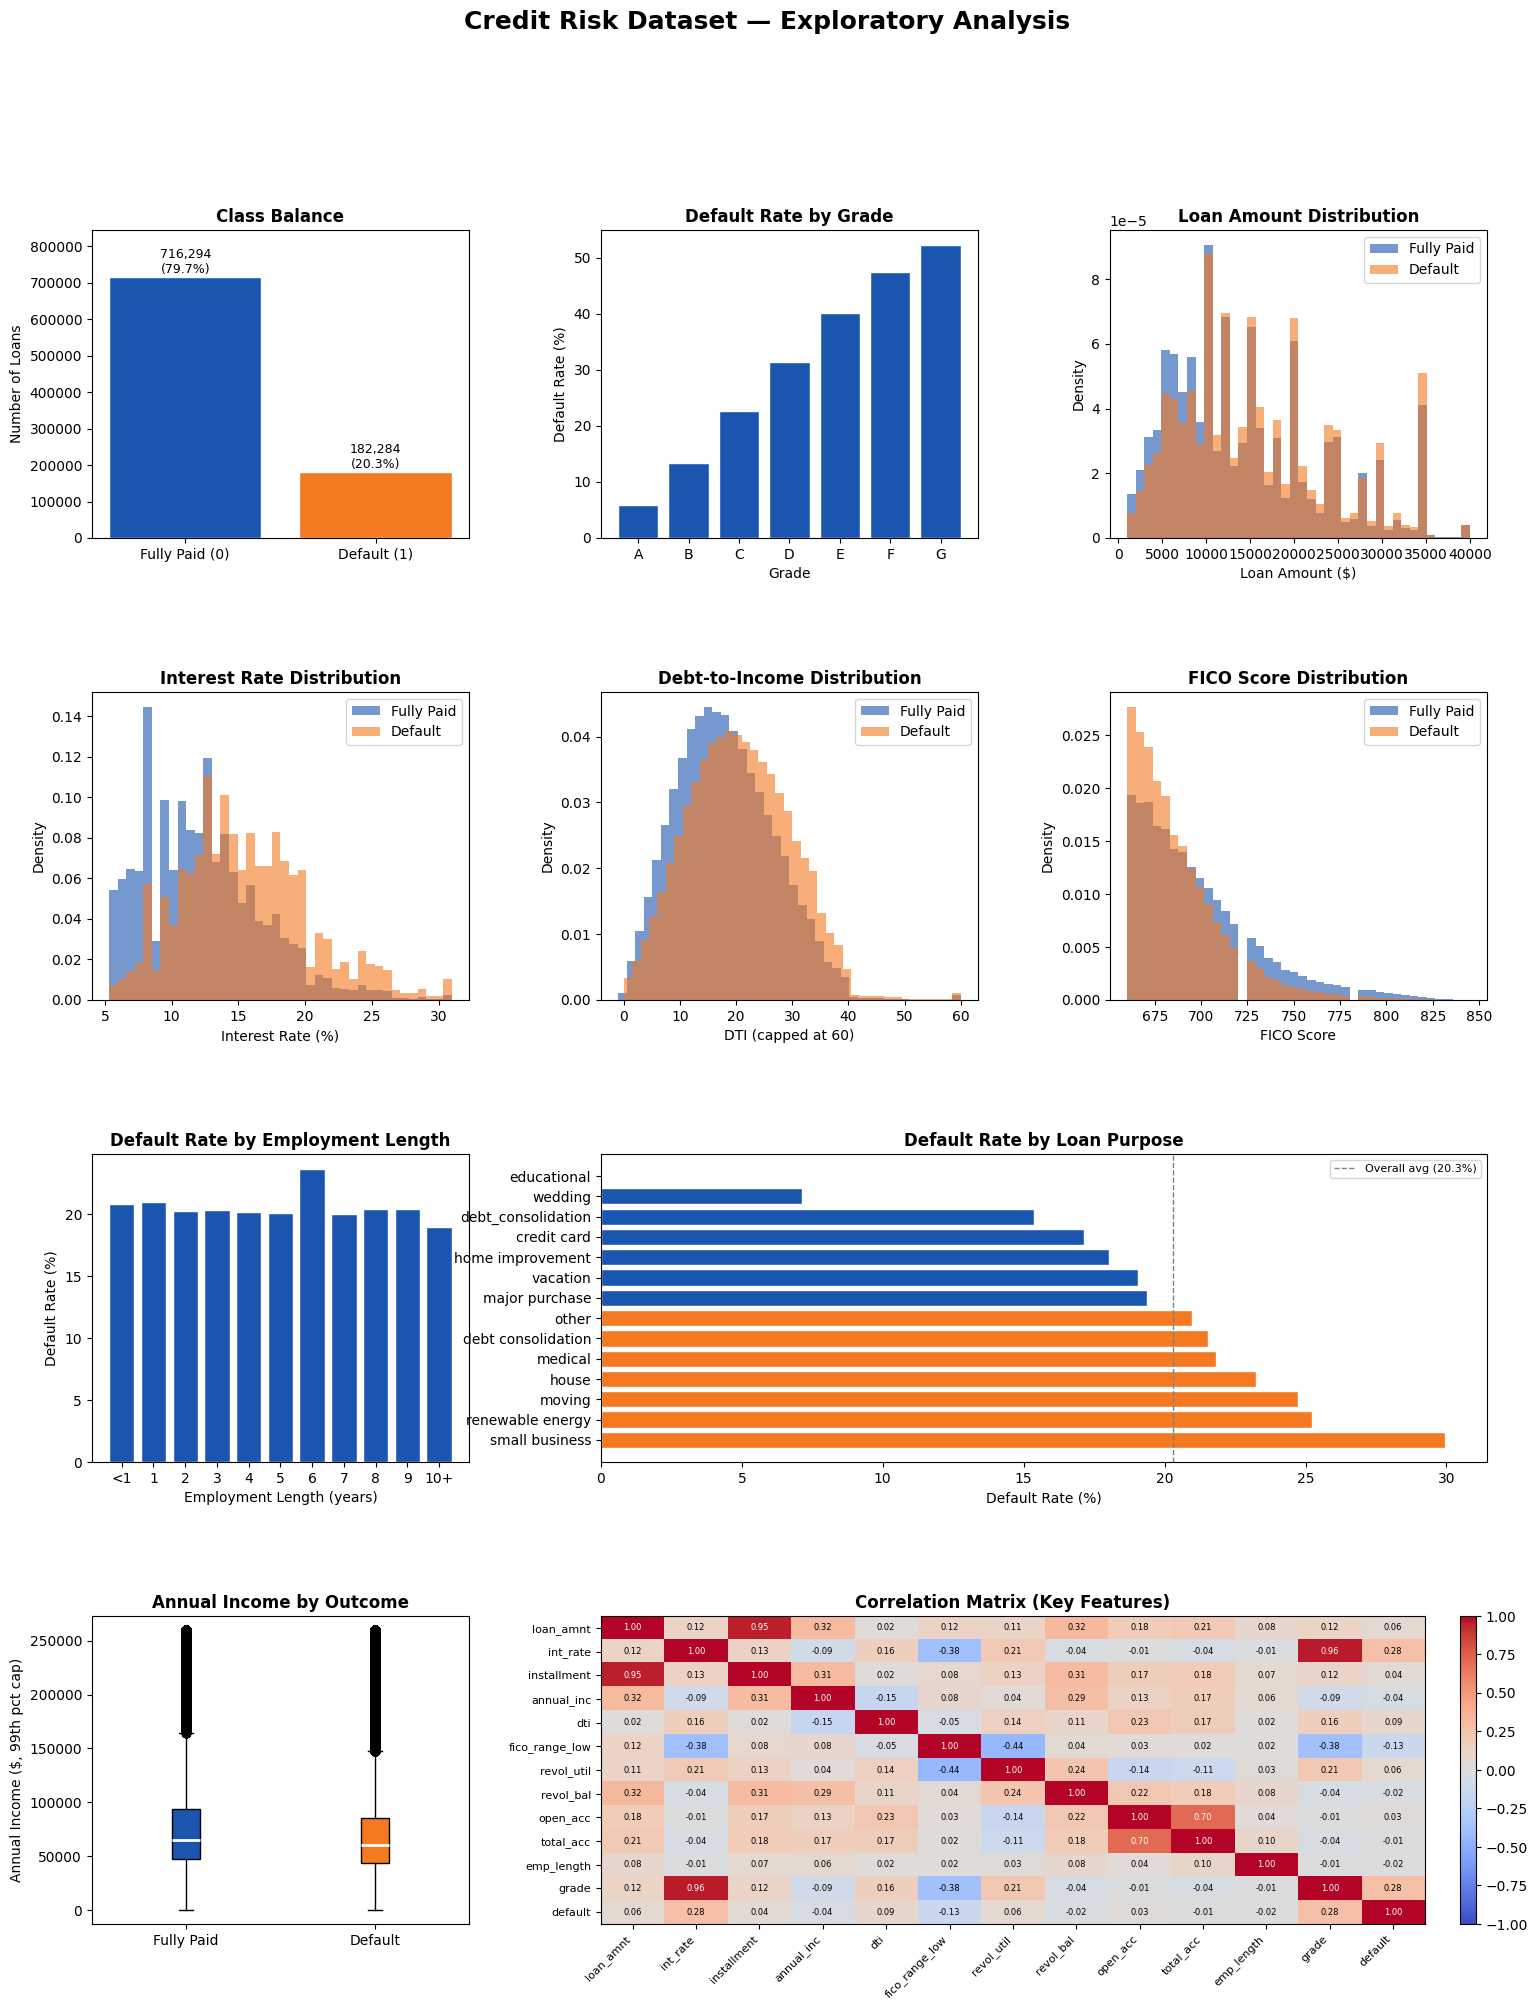

Visualizations saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 22))
fig.suptitle("Credit Risk Dataset — Exploratory Analysis", fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.35)

# 1. Class Balance
ax1 = fig.add_subplot(gs[0, 0])
counts = df["default"].value_counts()
bars = ax1.bar(["Fully Paid (0)", "Default (1)"], counts.values,
               color=["#1A56B0", "#F47920"], edgecolor="white")
ax1.set_title("Class Balance", fontweight="bold")
ax1.set_ylabel("Number of Loans")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
             f"{val:,}\n({val/len(df):.1%})", ha="center", va="bottom", fontsize=9)
ax1.set_ylim(0, counts.max() * 1.18)

# 2. Default Rate by Grade
ax2 = fig.add_subplot(gs[0, 1])
grade_labels = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E", 6: "F", 7: "G"}
grade_default = df.groupby("grade")["default"].mean().reset_index()
grade_default["label"] = grade_default["grade"].map(grade_labels)
ax2.bar(grade_default["label"], grade_default["default"] * 100,
        color="#1A56B0", edgecolor="white")
ax2.set_title("Default Rate by Grade", fontweight="bold")
ax2.set_ylabel("Default Rate (%)")
ax2.set_xlabel("Grade")

# 3. Loan Amount Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df.loc[df["default"] == 0, "loan_amnt"], bins=40,
         alpha=0.6, color="#1A56B0", label="Fully Paid", density=True)
ax3.hist(df.loc[df["default"] == 1, "loan_amnt"], bins=40,
         alpha=0.6, color="#F47920", label="Default", density=True)
ax3.set_title("Loan Amount Distribution", fontweight="bold")
ax3.set_xlabel("Loan Amount ($)")
ax3.set_ylabel("Density")
ax3.legend()

# 4. Interest Rate Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df.loc[df["default"] == 0, "int_rate"], bins=40,
         alpha=0.6, color="#1A56B0", label="Fully Paid", density=True)
ax4.hist(df.loc[df["default"] == 1, "int_rate"], bins=40,
         alpha=0.6, color="#F47920", label="Default", density=True)
ax4.set_title("Interest Rate Distribution", fontweight="bold")
ax4.set_xlabel("Interest Rate (%)")
ax4.set_ylabel("Density")
ax4.legend()

# 5. DTI Distribution
ax5 = fig.add_subplot(gs[1, 1])
dti_cap = 60
ax5.hist(df.loc[df["default"] == 0, "dti"].clip(upper=dti_cap), bins=40,
         alpha=0.6, color="#1A56B0", label="Fully Paid", density=True)
ax5.hist(df.loc[df["default"] == 1, "dti"].clip(upper=dti_cap), bins=40,
         alpha=0.6, color="#F47920", label="Default", density=True)
ax5.set_title("Debt-to-Income Distribution", fontweight="bold")
ax5.set_xlabel("DTI (capped at 60)")
ax5.set_ylabel("Density")
ax5.legend()

# 6. FICO Score Distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df.loc[df["default"] == 0, "fico_range_low"], bins=40,
         alpha=0.6, color="#1A56B0", label="Fully Paid", density=True)
ax6.hist(df.loc[df["default"] == 1, "fico_range_low"], bins=40,
         alpha=0.6, color="#F47920", label="Default", density=True)
ax6.set_title("FICO Score Distribution", fontweight="bold")
ax6.set_xlabel("FICO Score")
ax6.set_ylabel("Density")
ax6.legend()

# 7. Default Rate by Employment Length
ax7 = fig.add_subplot(gs[2, 0])
emp_default = df.groupby("emp_length")["default"].mean() * 100
ax7.bar(emp_default.index.astype(int), emp_default.values,
        color="#1A56B0", edgecolor="white")
ax7.set_title("Default Rate by Employment Length", fontweight="bold")
ax7.set_xlabel("Employment Length (years)")
ax7.set_ylabel("Default Rate (%)")
ax7.set_xticks(range(0, 11))
ax7.set_xticklabels(["<1","1","2","3","4","5","6","7","8","9","10+"])

# 8. Default Rate by Loan Purpose
ax8 = fig.add_subplot(gs[2, 1:])
purpose_cols = [c for c in df.columns if c.startswith("purpose_")]
if purpose_cols:
    purpose_rates = {}
    baseline_mask = df[purpose_cols].sum(axis=1) == 0
    purpose_rates["debt_consolidation"] = df.loc[baseline_mask, "default"].mean() * 100
    for col in purpose_cols:
        label = col.replace("purpose_", "").replace("_", " ")
        purpose_rates[label] = df.loc[df[col] == 1, "default"].mean() * 100
    purposes = sorted(purpose_rates.items(), key=lambda x: x[1], reverse=True)
    labels, rates = zip(*purposes)
    colors = ["#F47920" if r > df["default"].mean() * 100 else "#1A56B0" for r in rates]
    ax8.barh(labels, rates, color=colors, edgecolor="white")
    ax8.set_title("Default Rate by Loan Purpose", fontweight="bold")
    ax8.set_xlabel("Default Rate (%)")
    ax8.axvline(x=df["default"].mean() * 100, color="gray",
                linestyle="--", linewidth=1, label=f"Overall avg ({df['default'].mean():.1%})")
    ax8.legend(fontsize=8)

# 9. Annual Income by Outcome (box plot)
ax9 = fig.add_subplot(gs[3, 0])
inc_cap = df["annual_inc"].quantile(0.99)
paid_inc = df.loc[df["default"] == 0, "annual_inc"].clip(upper=inc_cap)
def_inc  = df.loc[df["default"] == 1, "annual_inc"].clip(upper=inc_cap)
bp = ax9.boxplot([paid_inc, def_inc], labels=["Fully Paid", "Default"],
                 patch_artist=True, medianprops={"color": "white", "linewidth": 2})
bp["boxes"][0].set_facecolor("#1A56B0")
bp["boxes"][1].set_facecolor("#F47920")
ax9.set_title("Annual Income by Outcome", fontweight="bold")
ax9.set_ylabel("Annual Income ($, 99th pct cap)")

# 10. Correlation Heatmap
ax10 = fig.add_subplot(gs[3, 1:])
core_features = [
    "loan_amnt", "int_rate", "installment", "annual_inc",
    "dti", "fico_range_low", "revol_util", "revol_bal",
    "open_acc", "total_acc", "emp_length", "grade", "default"
]
core_features = [c for c in core_features if c in df.columns]
corr = df[core_features].corr()
im = ax10.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax10.set_xticks(range(len(core_features)))
ax10.set_yticks(range(len(core_features)))
ax10.set_xticklabels(core_features, rotation=45, ha="right", fontsize=8)
ax10.set_yticklabels(core_features, fontsize=8)
ax10.set_title("Correlation Matrix (Key Features)", fontweight="bold")
plt.colorbar(im, ax=ax10, fraction=0.03, pad=0.04)
for i in range(len(core_features)):
    for j in range(len(core_features)):
        val = corr.values[i, j]
        ax10.text(j, i, f"{val:.2f}", ha="center", va="center",
                  fontsize=6, color="white" if abs(val) > 0.5 else "black")

plt.savefig("credit_risk_visualizations.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Visualizations saved.")

In [ ]:
df.to_csv("credit_risk_cleaned.csv", index=False)